# Radiation sensors: which series moved, and when


**notebook version**: `1` (28 Jul 2026)


## ℹ️ About this notebook

`30_PRODUCTS/01_METEO_SW_IN_2004-2025.ipynb` establishes that `SW_IN_T1_47_1` does not step at the
January 2016 acquisition change, and reports two changes that the same scan finds elsewhere. This
notebook is the full treatment of that scan. It **computes and exports nothing**: it attributes
every level change in the site's radiation record to a particular sensor, so that the statements
`01` and `03` make about their own products rest on measurements rather than on assertion.

**Why a fourth sensor.** `01` compares three series — the tower pyranometer at 47 m, NABEL's at
49 m, and MeteoSwiss Lägern. Three sensors give three pairwise ratios, which is enough to
attribute a change so long as only one sensor moves at a time and all three overlap. NABEL ends in
2018, so after that only one ratio survives and nothing can be attributed at all. Adding the
**co-located PAR sensor at 47 m** gives a fourth witness that runs the whole record, and turns the
post-2018 period from unattributable into decidable.

**The four series are not four independent instruments in the same sense**, and the notebook is
explicit about it: the tower pyranometer and the tower PAR sensor share a mast, a logger and a
maintenance history, so a fault in what they share moves both. What they do not share is their
optics and their calibration, which is what a level change of this kind lives in.

**What it concludes.** Four level changes exist in this record and none of them is at 2016:

| when | which sensor moved | size | documented |
|---|---|---|---|
| October 2010 | MeteoSwiss Lägern | about +5 % | yes, in the reference file itself |
| from 2013 | the tower pyranometer | about +3 % | no |
| from 2022 | the tower PAR sensor | about −7 % and continuing | no |
| January 2016 | none | — | — |
| December 2021 | none | — | — |


***


## 📇 Data sources

**Files**

- `30_PRODUCTS/01_METEO_SW_IN_GAPFILLED_2004-2025.parquet` — the `SW_IN` product. Only its
  **measured** records (`FLAG_SW_IN_T1_47_1_ISFILLED == 0`) are used, so no modelled value enters
  any comparison here
- `30_PRODUCTS/03_METEO_PPFD_IN_GAPFILLED_2004-2025.parquet` — the `PPFD_IN` product, measured
  records only, on the same basis
- `10_REFERENCE/MeteoSwiss_LAE_30MIN_2004-2025.parquet` — MeteoSwiss Lägern, 2.5 km, 845 m,
  the whole record

**Database**

- `SW_IN_NABEL_T1_49_1` — NABEL, 49 m, same tower, 2004 to the end of 2018. It is held in no file,
  so it is downloaded from InfluxDB as `01` downloads it. It exists under **one** data version
  (`meteoscreening_diive`), so there is nothing to merge

**Legend**

- NABEL ... [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), a national air-quality network operated by a different institution
- mst ... ETH data, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... ETH data, meteoscreening with [diive](https://github.com/holukas/diive)


## ⏱️ Timestamp convention

The two products are stored on `TIMESTAMP_MID` and this notebook works on it throughout. The
database returns `TIMESTAMP_END`, so the NABEL download passes through
`TimestampSanitizer(output_middle_timestamp=True)` as in `01`; the MeteoSwiss reference is stored
on `TIMESTAMP_END` and is shifted back 15 minutes. A disagreement would show as a correlation
maximum away from lag zero, which is asserted below.


## 🧭 Method

**Ratios, not differences.** A radiometer's error is multiplicative — a sensitivity 3 % wrong
reads 3 % low at every irradiance — so every comparison is a ratio and every change is a
percentage.

**One sensor moves; the ratios say which.** A calibration change at one sensor moves every ratio
that sensor appears in, and no other. With *n* sensors there are *n(n−1)/2* ratios and each sensor
appears in *n−1* of them, so the pattern of which ratios move identifies the sensor uniquely — the
same argument `02` makes for `TA` with three temperature sensors, and the reason a single reference
can date a change but cannot attribute it.

**Three controls**, each of which was capable of manufacturing a change that is not one:

- **Season.** Medians are taken per calendar month and averaged over months, and only
  April-September enters. Snow and rime on an upward-facing sensor act in winter, and so do the
  large horizon differences between two sites at low sun; both read as a calibration change.
- **Illumination.** Only half-hours whose *potential* radiation exceeds 300 W m⁻² enter, and both
  members of a ratio must exceed 50 W m⁻². Potential radiation is astronomical and cannot drift,
  which is what makes it a safe selector — selecting on a *measured* series would bias the ratio
  towards it.
- **How sunny the year was.** A ratio between two sensors sees the same weather in both members
  and so is immune to this. A ratio against potential radiation is **not**, and an earlier version
  of this analysis was misled by exactly that: a clear-sky index rises in a sunny year because more
  half-hours sit near the clear-sky envelope, which was read as a drift of the tower. Ratios
  between sensors are used throughout, and the clear-sky index appears only where it is labelled.


***


## ⚙️ Settings


In [1]:
DIRCONF = r'F:\dev\poet\configs'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET)
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution; TimestampSanitizer raises if it disagrees
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# This notebook exports nothing, so it has no OUTNAME/OUTPATH. It only reads.
DATADIR = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO")

SWIN_FILE = DATADIR + r"\30_PRODUCTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet"
SWIN_COL, SWIN_FLAG = "SW_IN_T1_47_1_gfXG", "FLAG_SW_IN_T1_47_1_ISFILLED"
PPFD_FILE = DATADIR + r"\30_PRODUCTS\03_METEO_PPFD_IN_GAPFILLED_2004-2025.parquet"
PPFD_COL, PPFD_FLAG = "PPFD_IN_T1_47_1_gfXG", "FLAG_PPFD_IN_T1_47_1_ISFILLED"
REFPATH = DATADIR + r"\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet"
REFCOL = "SW_IN_LAE_MS"

# The four series, under the short names used throughout. Order matters only for display.
TOWER_SW = 'tower SW_IN 47 m'
NABEL_SW = 'NABEL SW_IN 49 m'
MS_SW = 'MeteoSwiss SW_IN'
TOWER_PPFD = 'tower PPFD_IN 47 m'


### Imports


In [2]:
from datetime import datetime
from itertools import combinations
from pathlib import Path
import importlib.metadata
import textwrap

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")


Last run: 2026-07-28 21:55:32
diive version: v0.91.0


### Captions


In [3]:
# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
# Defined here, above the first cell that calls either. Copied as-is from notebook 02.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    if fig.get_layout_engine() is not None:
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')


***


## ⬇️ NABEL data from the database

The only series here that is held in no file. Everything else is read from a product or a reference.


In [4]:
%%time

dbc = InfluxIO(dirconf=DIRCONF)

BUCKET = 'ch-lae_processed'
FIELDS = ['SW_IN_NABEL_T1_49_1']
MEASUREMENTS = ['SW']
START = '2004-01-01 00:00:01'
STOP = '2026-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_diive'

nabel_swin, _, _ = dbc.download(
    bucket=BUCKET, measurements=MEASUREMENTS, fields=FIELDS,
    start=START, stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)
nabel_swin = TimestampSanitizer(data=nabel_swin, output_middle_timestamp=True,
                                nominal_freq=REQUIRED_TIME_RESOLUTION).get()
nabel_swin


> Reading configuration files was successful.

v Connection to database works.

> DOWNLOADING from bucket ch-lae_processed: variables ['SW_IN_NABEL_T1_49_1'] from measurements 
['SW'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 7.22 s
Wall time: 9.74 s


,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,
2004-01-01 00:15:00,0.0
2004-01-01 00:45:00,0.0
2004-01-01 01:15:00,0.0
2004-01-01 01:45:00,0.0
2004-01-01 02:15:00,0.0
...,...
2018-12-31 21:45:00,0.0
2018-12-31 22:15:00,0.0
2018-12-31 22:45:00,0.0


## ❇️ Assemble the four series


In [5]:
# The two products, measured records only. A modelled value is partly a function of the very
# reference it would then be compared against, so admitting one would make some of the ratios
# below partly self-referential.
_sw = pd.read_parquet(SWIN_FILE)
_pf = pd.read_parquet(PPFD_FILE)
print(f"SW_IN  product: {len(_sw):,} records, "
      f"{100 * (_sw[SWIN_FLAG] == 0).mean():.1f} % measured")
print(f"PPFD_IN product: {len(_pf):,} records, "
      f"{100 * (_pf[PPFD_FLAG] == 0).mean():.1f} % measured")

rad = pd.DataFrame(index=_sw.index)
rad[TOWER_SW] = _sw[SWIN_COL].where(_sw[SWIN_FLAG] == 0)
rad[TOWER_PPFD] = _pf[PPFD_COL].where(_pf[PPFD_FLAG] == 0)
rad[NABEL_SW] = nabel_swin['SW_IN_NABEL_T1_49_1']

# The reference is stored on TIMESTAMP_END. For 30MIN data the bin (t-30min, t] has its midpoint
# at t-15min, so the index is shifted back by 15 minutes.
_ref = pd.read_parquet(REFPATH)[[REFCOL]]
_ref.index = _ref.index - pd.Timedelta(minutes=15)
_ref.index.name = rad.index.name
rad[MS_SW] = _ref[REFCOL]

SERIES = [TOWER_SW, NABEL_SW, MS_SW, TOWER_PPFD]
rad = rad[SERIES]

# Guards. The 15-minute shift is proved rather than assumed, and so is the index.
_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([rad[TOWER_SW].rename('t'), rad[MS_SW].shift(_off).rename('r')], axis=1).dropna()
    _j = _j[_j['r'] > 20]  # daytime only: at night both are ~0 and carry no timing information
    _scores[_off] = _j['t'].corr(_j['r'])
    print(f"  reference offset {_off:+d} x 30min: daytime corr {_scores[_off]:.4f}")
assert max(_scores, key=_scores.get) == 0, f"the reference is mis-aligned: {_scores}"
assert not rad.index.duplicated().any(), "duplicate timestamps in the assembled frame"
assert (rad.index.to_series().diff().dropna() == pd.Timedelta('30min')).all(), \
    "the assembled index is not continuous 30MIN"

tabcap("the four series, their coverage and the period each spans. Only measured records are "
       "counted for the two tower products")
_cov = pd.DataFrame({
    'records': rad.notna().sum(),
    'first': [rad[c].dropna().index[0].date() for c in SERIES],
    'last': [rad[c].dropna().index[-1].date() for c in SERIES],
})
display(_cov)


SW_IN  product: 385,728 records, 91.2 % measured
PPFD_IN product: 385,728 records, 95.7 % measured
  reference offset -1 x 30min: daytime corr 0.9288
  reference offset +0 x 30min: daytime corr 0.9648
  reference offset +1 x 30min: daytime corr 0.9069
Table - the four series, their coverage and the period each spans. Only measured records are counted
for the two tower products



,records,first,last
tower SW_IN 47 m,351726,2005-09-14,2025-12-31
NABEL SW_IN 49 m,262774,2004-01-01,2018-12-31
MeteoSwiss SW_IN,384126,2004-02-01,2025-12-31
tower PPFD_IN 47 m,369124,2004-09-20,2025-12-31


***


## 🧮 Helpers


In [6]:
# The comparison machinery. See the method section above for why each control is here.
WELL_LIT = 300.0        # W m-2 of POTENTIAL radiation: astronomical, so it cannot drift
MIN_IRRADIANCE = 50.0   # measured, at both members of a ratio; W m-2 for SW, umol m-2 s-1 for PPFD
SUMMER_MONTHS = [4, 5, 6, 7, 8, 9]
BASELINE_YEARS = (2006, 2010)  # the years every ratio is expressed relative to: before the first
                               # event found below, and after the tower record has settled

POTRAD = dv.variables.potrad(timestamp_index=rad.index, lat=SITE_LAT, lon=SITE_LON,
                             utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
USABLE = (POTRAD > WELL_LIT) & rad.index.month.isin(SUMMER_MONTHS)
print(f"usable half-hours (Apr-Sep, potential radiation > {WELL_LIT:.0f} W m-2): "
      f"{int(USABLE.sum()):,} of {len(rad):,}")


def ratio_by_year(num: str, den: str, min_records: int = 100) -> pd.Series:
    """Month-matched yearly median of `num`/`den` over usable half-hours.

    Monthly medians first, then the mean over calendar months, so a year that happens to be short
    of one month is not compared against one that is not. Raises rather than returning a thin
    result: a ratio built from a handful of half-hours plots exactly like one built from a
    thousand, and there would be nothing in the output to tell them apart.
    """
    _j = rad.loc[USABLE, [num, den]].dropna()
    _j = _j[(_j[num] > MIN_IRRADIANCE) & (_j[den] > MIN_IRRADIANCE)]
    if len(_j) < min_records * 12:
        raise ValueError(f"{num} / {den}: only {len(_j)} usable half-hours, too few to build "
                         f"monthly medians from")
    _r = _j[num] / _j[den]
    _m = _r.groupby([_r.index.year, _r.index.month]).median()
    _m.index.names = ['year', 'month']
    _n = _r.groupby([_r.index.year, _r.index.month]).count()
    _m = _m[_n >= min_records]
    if _m.empty:
        raise ValueError(f"{num} / {den}: no calendar month reaches {min_records} records")
    return _m.groupby(level=0).mean()


def step_at(series: pd.Series, year: int, span: int = 3) -> float:
    """Percentage change of a yearly ratio across `year`, over `span` years either side.

    The candidate year is excluded from both sides: a change that happens inside a year belongs to
    neither era, and including it would halve the step it is meant to measure. Returns nan rather
    than a number when either side is too thin, so a year at the edge of a record cannot win a
    scan by having almost no data behind it.
    """
    _pre = series.reindex(range(year - span, year)).dropna()
    _post = series.reindex(range(year + 1, year + 1 + span)).dropna()
    if len(_pre) < 2 or len(_post) < 2:
        return float('nan')
    return 100 * (_post.mean() / _pre.mean() - 1)


def moved(scan: pd.DataFrame, year: int, threshold: float = 2.0) -> dict:
    """Which pairs changed at `year`, and which sensor that implicates.

    A sensor is implicated when every pair it appears in moved and no pair it does not appear in
    did. Returning the verdict rather than printing it lets the assertions below test it.
    """
    _row = scan.loc[year].dropna()
    _big = {_p for _p in _row.index if abs(_row[_p]) >= threshold}
    _verdict = []
    for _s in SERIES:
        _mine = {_p for _p in _row.index if _s in _p}
        _theirs = set(_row.index) - _mine
        if _mine and _mine <= _big and not (_theirs & _big):
            _verdict.append(_s)
    return {'year': year, 'pairs that moved': sorted(_big), 'implicates': _verdict}


usable half-hours (Apr-Sep, potential radiation > 300 W m-2): 93,950 of 385,728


### Negative controls


In [7]:
# The guards guard. Every helper here can return a plausible number from input that should stop
# it, so each failure path is exercised before any of them is trusted.
for _thresh, _which in [(1_000_000, 'too few half-hours in total'),
                        (5_000, 'enough in total, but no single calendar month')]:
    try:
        ratio_by_year(TOWER_SW, NABEL_SW, min_records=_thresh)
    except ValueError as _exc:
        print(f"OK, ratio_by_year raised on '{_which}': {_exc}")
    else:
        raise AssertionError(f"(!) ratio_by_year accepted a threshold no data can meet ({_which}).")

_probe = ratio_by_year(TOWER_SW, MS_SW)
assert np.isnan(step_at(_probe, 1990)), "(!) step_at returned a number for a year off the record"
assert np.isnan(step_at(_probe, int(_probe.index.max()))), \
    "(!) step_at returned a number for the last year of the record, which has no years after it"
print("OK, step_at returns nan where one side of the comparison does not exist")

# And the attribution rule must refuse to name a sensor when the pattern does not identify one.
# Two sensors moving at once looks exactly like a table with several large entries; if `moved`
# named a sensor anyway, every such year would produce a confident wrong answer.
_fake = pd.DataFrame([{f'{TOWER_SW} / {NABEL_SW}': 9.0, f'{TOWER_SW} / {MS_SW}': 9.0,
                       f'{NABEL_SW} / {MS_SW}': 9.0, f'{TOWER_SW} / {TOWER_PPFD}': 9.0,
                       f'{NABEL_SW} / {TOWER_PPFD}': 9.0, f'{MS_SW} / {TOWER_PPFD}': 9.0}],
                     index=[2000])
assert moved(_fake, 2000)['implicates'] == [], \
    "(!) the attribution rule named a sensor when every pair moved, which identifies nothing"
print("OK, the attribution rule names no sensor when the pattern does not identify one")


OK, ratio_by_year raised on 'too few half-hours in total': tower SW_IN 47 m / NABEL SW_IN 49 m: only 51498 usable half-hours, too few to build monthly medians from
OK, ratio_by_year raised on 'enough in total, but no single calendar month': tower SW_IN 47 m / NABEL SW_IN 49 m: only 51498 usable half-hours, too few to build monthly medians from
OK, step_at returns nan where one side of the comparison does not exist
OK, the attribution rule names no sensor when the pattern does not identify one


***


## 📊 Every pairwise ratio


In [8]:
# All six pairwise ratios among the four series, year by year.
PAIRS = [(f'{_a} / {_b}', _a, _b) for _a, _b in combinations(SERIES, 2)]
RATIOS = {}
for _label, _a, _b in PAIRS:
    try:
        RATIOS[_label] = ratio_by_year(_a, _b)
    except ValueError as _exc:
        print(f"skipped {_label}: {_exc}")
ratio_table = pd.DataFrame(RATIOS).sort_index()
ratio_table.index.name = 'YEAR'

BASE = ratio_table.loc[BASELINE_YEARS[0]:BASELINE_YEARS[1]].mean()
relative = 100 * (ratio_table / BASE - 1)
tabcap(f"every pairwise ratio year by year, as a percentage of its own "
       f"{BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} mean. A ratio is a comparison of two sensors "
       f"only; a row is not a statement about how sunny a year was")
display(relative.round(2))
assert len(RATIOS) == 6, f"expected six pairwise ratios, built {len(RATIOS)}"


Table - every pairwise ratio year by year, as a percentage of its own 2006-2010 mean. A ratio is a
comparison of two sensors only; a row is not a statement about how sunny a year was



,tower SW_IN 47 m / NABEL SW_IN 49 m,tower SW_IN 47 m / MeteoSwiss SW_IN,tower SW_IN 47 m / tower PPFD_IN 47 m,NABEL SW_IN 49 m / MeteoSwiss SW_IN,NABEL SW_IN 49 m / tower PPFD_IN 47 m,MeteoSwiss SW_IN / tower PPFD_IN 47 m
YEAR,,,,,,
2004,NaN,NaN,NaN,-1.68,1.05,2.25
2005,4.49,1.57,2.23,-2.25,-1.49,1.00
2006,0.52,-0.35,-0.42,-0.94,-0.59,0.30
2007,-0.20,-0.43,-0.46,-0.19,-0.14,-0.63
2008,-0.08,-0.69,0.07,-0.70,0.43,0.41
2009,-0.32,0.15,0.15,0.59,0.12,0.30
2010,0.08,1.31,0.66,1.23,0.18,-0.38
2011,-0.58,-5.50,-1.27,-5.08,-1.41,4.16
2012,-0.56,-4.41,-0.21,-4.33,0.01,4.25


### The blind scan

The events are found by scanning every year of every ratio, and only then explained. Letting a maintenance record or a suspicion choose the year first would find only changes somebody already knew about.


In [9]:
# The blind scan. The same three-years-either-side change is computed at every year of every
# ratio, so the events are found by the data rather than chosen and then confirmed.
scan = pd.DataFrame({_l: {_y: step_at(_s, _y) for _y in _s.index}
                     for _l, _s in RATIOS.items()}).sort_index()
scan.index.name = 'YEAR'
tabcap("the change across each year, in each pairwise ratio. A calibration change at one sensor "
       "fills the columns that sensor appears in and leaves the others empty, which is what makes "
       "a row attributable")
display(scan.round(2))

EVENT_THRESHOLD = 2.0
tabcap(f"every year at which at least one ratio changes by {EVENT_THRESHOLD} % or more, with the "
       f"sensor the pattern implicates. A year that implicates nothing is a year where the "
       f"evidence does not identify a single sensor")
_rows = []
for _y in scan.index:
    _v = moved(scan, _y, EVENT_THRESHOLD)
    if _v['pairs that moved']:
        _rows.append({'year': _y, 'pairs that moved': len(_v['pairs that moved']),
                      'implicates': ', '.join(_v['implicates']) or '(not identified)'})
events = pd.DataFrame(_rows).set_index('year')
display(events)


Table - the change across each year, in each pairwise ratio. A calibration change at one sensor
fills the columns that sensor appears in and leaves the others empty, which is what makes a row
attributable



,tower SW_IN 47 m / NABEL SW_IN 49 m,tower SW_IN 47 m / MeteoSwiss SW_IN,tower SW_IN 47 m / tower PPFD_IN 47 m,NABEL SW_IN 49 m / MeteoSwiss SW_IN,NABEL SW_IN 49 m / tower PPFD_IN 47 m,MeteoSwiss SW_IN / tower PPFD_IN 47 m
YEAR,,,,,,
2004,NaN,NaN,NaN,NaN,NaN,NaN
2005,NaN,NaN,NaN,NaN,NaN,NaN
2006,NaN,NaN,NaN,1.91,0.36,-1.57
2007,-2.54,-0.35,-0.61,2.04,0.59,-1.06
2008,-1.84,-1.61,-0.61,0.04,0.38,1.13
2009,-0.43,-2.39,-0.01,-2.13,-0.31,2.65
2010,0.58,-3.63,0.71,-4.48,-0.02,4.56
2011,1.57,-3.00,1.74,-4.91,0.45,4.73
2012,2.74,-0.48,3.19,-3.48,1.40,3.51


Table - every year at which at least one ratio changes by 2.0 % or more, with the sensor the pattern
implicates. A year that implicates nothing is a year where the evidence does not identify a single
sensor



,pairs that moved,implicates
year,,
2007,2,(not identified)
2009,3,MeteoSwiss SW_IN
2010,3,MeteoSwiss SW_IN
2011,3,MeteoSwiss SW_IN
2012,4,(not identified)
2013,2,(not identified)
2014,3,tower SW_IN 47 m
2021,2,tower PPFD_IN 47 m
2022,2,tower PPFD_IN 47 m


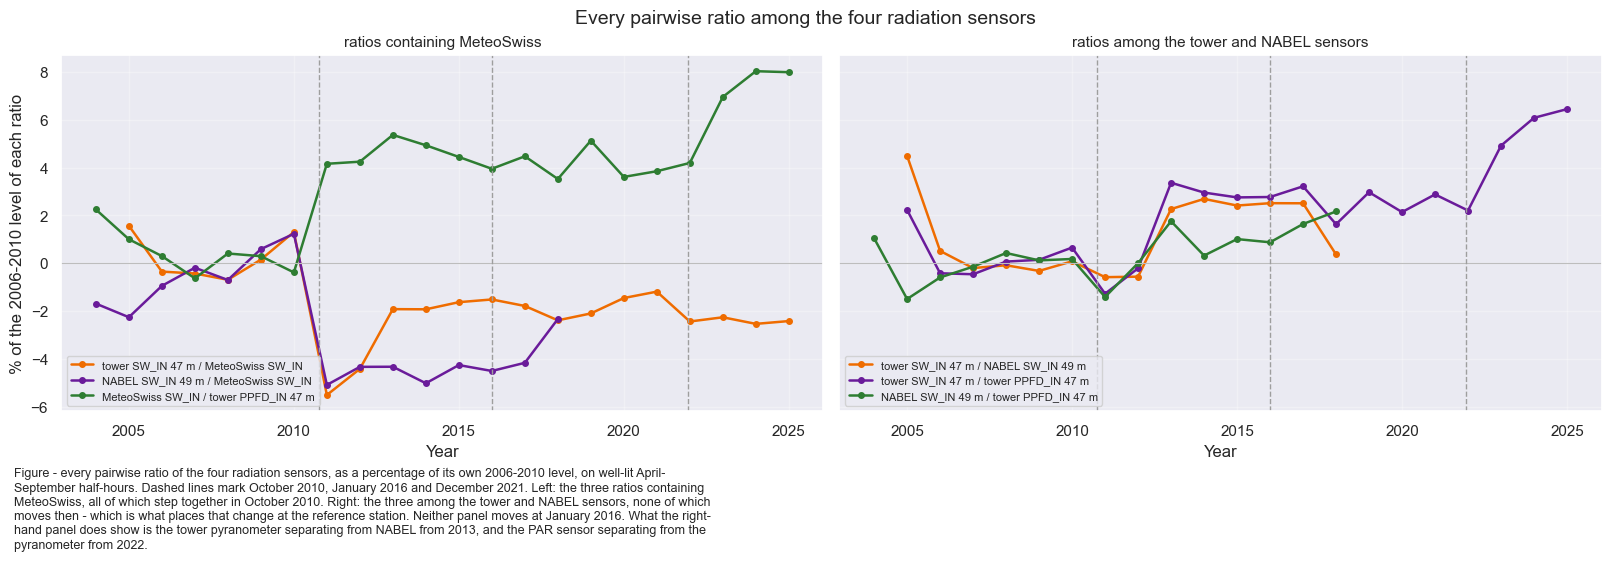

In [10]:
# All six ratios on one pair of axes, split by whether MeteoSwiss is one of the two members, so
# the October 2010 event does not dominate the panel that has to show everything else.
fig, axs = plt.subplots(ncols=2, figsize=(16, 5.5), dpi=100, layout="constrained", sharey=True)
fig.suptitle("Every pairwise ratio among the four radiation sensors", fontsize=14)

_ms_pairs = [_l for _l in RATIOS if MS_SW in _l]
_other_pairs = [_l for _l in RATIOS if MS_SW not in _l]
_colours = ['#EF6C00', '#6A1B9A', '#2E7D32', '#1565C0', '#C62828', '#00838F']

for _ax, _group, _title in [(axs[0], _ms_pairs, 'ratios containing MeteoSwiss'),
                            (axs[1], _other_pairs, 'ratios among the tower and NABEL sensors')]:
    for _l, _c in zip(_group, _colours):
        _ax.plot(relative.index, relative[_l], color=_c, lw=1.8, marker='o', ms=4, label=_l)
    _ax.axhline(0, color='#BDBDBD', lw=0.8)
    _ax.set_title(_title, fontsize=11)
    _ax.set_xlabel("Year")
    _ax.grid(alpha=0.3)
    _ax.legend(fontsize=8, loc='lower left')
    for _x in (2010.75, 2016, 2021.95):
        _ax.axvline(_x, color='#9E9E9E', lw=1.0, ls='--')

axs[0].set_ylabel(f"% of the {BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} level of each ratio")
figcap(fig, "every pairwise ratio of the four radiation sensors, as a percentage of its own "
            f"{BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} level, on well-lit April-September "
            "half-hours. Dashed lines mark October 2010, January 2016 and December 2021. Left: "
            "the three ratios containing MeteoSwiss, all of which step together in October 2010. "
            "Right: the three among the tower and NABEL sensors, none of which moves then - which "
            "is what places that change at the reference station. Neither panel moves at January "
            "2016. What the right-hand panel does show is the tower pyranometer separating from "
            "NABEL from 2013, and the PAR sensor separating from the pyranometer from 2022.")


***


## 1️⃣ October 2010: the reference station

The largest level change in this record is not at this site.


In [11]:
EVENT_2010 = int(scan[f'{TOWER_SW} / {MS_SW}'].abs().idxmax())
print(f"largest change in the tower-against-MeteoSwiss ratio anywhere: {EVENT_2010}\n")
_v = moved(scan, EVENT_2010, EVENT_THRESHOLD)
for _p in scan.columns:
    print(f"  {_p:<42s} {scan.loc[EVENT_2010, _p]:+6.2f} %"
          f"{'   <- moved' if _p in _v['pairs that moved'] else ''}")
print(f"\nimplicates: {_v['implicates']}")

# The cause, read out of the reference file rather than claimed. Diffuse radiation needs a shading
# device; a station that begins reporting it has had its radiation instrumentation rebuilt.
_diffuse_start = pd.read_parquet(REFPATH)['SW_IN_DIFF_LAE_MS'].dropna().index[0]
print(f"\nMeteoSwiss Laegern first reports diffuse radiation: {_diffuse_start:%d %b %Y %H:%M}")

assert _v['implicates'] == [MS_SW], (
    f"the {EVENT_2010} change no longer implicates the reference station alone - it implicates "
    f"{_v['implicates']}, and every notebook that uses this reference has to be re-read")
assert _diffuse_start.year in (EVENT_2010 - 1, EVENT_2010), (
    "the reference station's new radiation channel no longer coincides with the step in its "
    "global radiation - the cause stated here is no longer supported")


largest change in the tower-against-MeteoSwiss ratio anywhere: 2010

  tower SW_IN 47 m / NABEL SW_IN 49 m         +0.58 %
  tower SW_IN 47 m / MeteoSwiss SW_IN         -3.63 %   <- moved
  tower SW_IN 47 m / tower PPFD_IN 47 m       +0.71 %
  NABEL SW_IN 49 m / MeteoSwiss SW_IN         -4.48 %   <- moved
  NABEL SW_IN 49 m / tower PPFD_IN 47 m       -0.02 %
  MeteoSwiss SW_IN / tower PPFD_IN 47 m       +4.56 %   <- moved

implicates: ['MeteoSwiss SW_IN']

MeteoSwiss Laegern first reports diffuse radiation: 06 Oct 2010 15:30


## 2️⃣ January 2016: nothing moved

The changeover that moved `TA` by 1.3 °C left both radiation series where they were.


In [12]:
BREAK_2016 = 2016
tabcap(f"the change across {BREAK_2016}, the year the tower's data logger was replaced, in every "
       f"ratio that spans it")
_row = scan.loc[BREAK_2016].dropna()
display(_row.rename(f'change across {BREAK_2016} (%)').to_frame().round(2))

print(f"largest change in any ratio across {BREAK_2016}: {_row.abs().max():.2f} %")
print(f"median |change| over all other years:            "
      f"{scan.drop(index=BREAK_2016).abs().median().median():.2f} %")

# The 2016 changeover replaced this tower's logger, so it can only have moved the two tower
# series. Ratios between the two references are carried in the table but are not what this
# assertion is about, and asserting on them would fail this cell for a reason it is not about.
_tower_pairs = [_p for _p in _row.index if TOWER_SW in _p or TOWER_PPFD in _p]
assert len(_tower_pairs) >= 3, "fewer tower pairs than expected span the changeover"
for _p in _tower_pairs:
    assert abs(_row[_p]) < EVENT_THRESHOLD, (
        f"{_p} changes by {_row[_p]:.2f} % across {BREAK_2016} - a tower series may have moved at "
        f"the logger replacement after all, and notebook 01 must be re-derived")
assert moved(scan, BREAK_2016, EVENT_THRESHOLD)['implicates'] == [], \
    f"{BREAK_2016} now implicates a sensor, which is the opposite of what this notebook concludes"
print(f"\nNo ratio involving either tower sensor changes by as much as {EVENT_THRESHOLD} % across "
      f"{BREAK_2016}.")


Table - the change across 2016, the year the tower's data logger was replaced, in every ratio that
spans it



,change across 2016 (%)
tower SW_IN 47 m / NABEL SW_IN 49 m,-0.99
tower SW_IN 47 m / MeteoSwiss SW_IN,-0.27
tower SW_IN 47 m / tower PPFD_IN 47 m,-0.41
NABEL SW_IN 49 m / MeteoSwiss SW_IN,1.35
NABEL SW_IN 49 m / tower PPFD_IN 47 m,0.86
MeteoSwiss SW_IN / tower PPFD_IN 47 m,-0.51


largest change in any ratio across 2016: 1.35 %
median |change| over all other years:            1.20 %

No ratio involving either tower sensor changes by as much as 2.0 % across 2016.


## 3️⃣ From 2013: the tower pyranometer, unattributed

The one change in the `SW_IN` product itself. It has no date and no documented cause, and the treatment here is correspondingly cautious.


In [13]:
# The year the scan itself picks out, rather than one chosen by eye: the first year after the
# MeteoSwiss event at which the pattern implicates the tower pyranometer.
EVENT_TOWER = next(_y for _y in scan.index
                   if _y > EVENT_2010 and moved(scan, _y, EVENT_THRESHOLD)['implicates'] == [TOWER_SW])
_v = moved(scan, EVENT_TOWER, EVENT_THRESHOLD)
print(f"the scan implicates the tower pyranometer at {EVENT_TOWER}\n")
for _p in scan.columns:
    print(f"  {_p:<42s} {scan.loc[EVENT_TOWER, _p]:+6.2f} %"
          f"{'   <- moved' if _p in _v['pairs that moved'] else ''}")

# Re-baselined on 2011-2012, the two complete years between the MeteoSwiss event and this one.
# Against the 2006-2010 baseline used elsewhere, every ratio containing MeteoSwiss still carries
# the 5 % October 2010 step, and reading this event off those columns would measure that instead -
# which is exactly what happened while this cell was being written.
LOCAL_BASE = (2011, 2012)
DEPARTURE = list(range(LOCAL_BASE[0], 2019))
_local = 100 * (ratio_table / ratio_table.loc[LOCAL_BASE[0]:LOCAL_BASE[1]].mean() - 1)
_cols = [_p for _p in _local.columns if TOWER_SW in _p]
tabcap(f"the tower pyranometer against each of the other three sensors, as a percentage of the "
       f"{LOCAL_BASE[0]}-{LOCAL_BASE[1]} level of each ratio - the years between the MeteoSwiss "
       f"event and this one, so that the earlier step is not inside the comparison")
display(_local.loc[DEPARTURE, _cols].round(2))

_worst = _local.loc[DEPARTURE, _cols].max().max()
print(f"\nlargest departure of the tower pyranometer from another sensor since {LOCAL_BASE[1]}: "
      f"{_worst:.2f} %")
print("It rises against all three at once, which places it on the pyranometer, but it develops "
      "over three years rather than stepping at a date and no maintenance record covers it. The "
      "fieldbook records no calibration of this CNR1 between its installation in 2005 and its "
      "removal in 2021.")

assert _v['implicates'] == [TOWER_SW], (
    f"the {EVENT_TOWER} change no longer implicates the tower pyranometer alone")
assert _worst < 5.0, (
    "the tower pyranometer's unattributed departure has grown past the field uncertainty of an "
    "instrument of this class - it can no longer be left uncorrected on the grounds given here")


the scan implicates the tower pyranometer at 2014

  tower SW_IN 47 m / NABEL SW_IN 49 m         +2.09 %   <- moved
  tower SW_IN 47 m / MeteoSwiss SW_IN         +2.40 %   <- moved
  tower SW_IN 47 m / tower PPFD_IN 47 m       +2.27 %   <- moved
  NABEL SW_IN 49 m / MeteoSwiss SW_IN         +0.29 %
  NABEL SW_IN 49 m / tower PPFD_IN 47 m       +1.06 %
  MeteoSwiss SW_IN / tower PPFD_IN 47 m       -0.29 %
Table - the tower pyranometer against each of the other three sensors, as a percentage of the
2011-2012 level of each ratio - the years between the MeteoSwiss event and this one, so that the
earlier step is not inside the comparison



,tower SW_IN 47 m / NABEL SW_IN 49 m,tower SW_IN 47 m / MeteoSwiss SW_IN,tower SW_IN 47 m / tower PPFD_IN 47 m
YEAR,,,
2011,-0.01,-0.57,-0.54
2012,0.01,0.57,0.54
2013,2.85,3.20,4.14
2014,3.28,3.19,3.72
2015,3.00,3.51,3.52
2016,3.10,3.63,3.54
2017,3.09,3.34,3.99
2018,0.94,2.71,2.39



largest departure of the tower pyranometer from another sensor since 2012: 4.14 %
It rises against all three at once, which places it on the pyranometer, but it develops over three years rather than stepping at a date and no maintenance record covers it. The fieldbook records no calibration of this CNR1 between its installation in 2005 and its removal in 2021.


## 4️⃣ December 2021: the radiometer was replaced


In [14]:
CNR4_YEAR = 2022
tabcap(f"the change across {CNR4_YEAR}, when the radiometer itself was replaced. NABEL ended in "
       f"2018, so only MeteoSwiss and the co-located PAR sensor reach this boundary - which is "
       f"the reason the PAR sensor is in this notebook at all")
_row = scan.loc[CNR4_YEAR].dropna()
display(_row.rename(f'change across {CNR4_YEAR} (%)').to_frame().round(2))

# One of the pyranometer's two surviving pairs DOES move here - the one against the PAR sensor -
# and it moves because the PAR sensor is falling, which is the subject of the next section. That
# is precisely what a per-pair threshold cannot tell you, and why this notebook has an attribution
# rule at all: a ratio says two sensors have separated, never which of them left.
#
# So the test is made two ways, neither of which a moving PAR sensor can trip. First, against
# MeteoSwiss, the one reference here that the scan does not implicate at this year. Second, on the
# attribution rule itself, which requires ALL of a sensor's pairs to move before naming it.
_v = moved(scan, CNR4_YEAR, EVENT_THRESHOLD)
print(f"\npairs that moved across {CNR4_YEAR}: {_v['pairs that moved']}")
print(f"implicates: {_v['implicates'] or '(not identified)'}")

assert abs(_row[f'{TOWER_SW} / {MS_SW}']) < EVENT_THRESHOLD, (
    f"the pyranometer changes by {_row[f'{TOWER_SW} / {MS_SW}']:.2f} % against MeteoSwiss across "
    f"the CNR1 -> CNR4 replacement - a homogenisation would be needed and notebook 01 does not "
    f"provide one")
assert TOWER_SW not in _v['implicates'], (
    f"the scan now implicates the pyranometer at {CNR4_YEAR}, the year its own sensor was "
    f"replaced - notebook 01's statement that the series is homogeneous across it no longer holds")
print(f"\nThe pyranometer does not step across its own replacement. Note that this boundary is "
      f"also where the mst screening ends and diive begins, so the two possible causes of a step "
      f"here are confounded; neither produces one.")


Table - the change across 2022, when the radiometer itself was replaced. NABEL ended in 2018, so
only MeteoSwiss and the co-located PAR sensor reach this boundary - which is the reason the PAR
sensor is in this notebook at all



,change across 2022 (%)
tower SW_IN 47 m / MeteoSwiss SW_IN,-0.84
tower SW_IN 47 m / tower PPFD_IN 47 m,3.07
MeteoSwiss SW_IN / tower PPFD_IN 47 m,3.32



pairs that moved across 2022: ['MeteoSwiss SW_IN / tower PPFD_IN 47 m', 'tower SW_IN 47 m / tower PPFD_IN 47 m']
implicates: ['tower PPFD_IN 47 m']

The pyranometer does not step across its own replacement. Note that this boundary is also where the mst screening ends and diive begins, so the two possible causes of a step here are confounded; neither produces one.


## 5️⃣ From 2022: the PAR sensor is still falling

The only finding here that is current, and the reason this notebook exists as more than a record of history.


In [15]:
# The PAR sensor is the one series still falling at the end of the record, so it is reported as a
# rate rather than as a step: a step has a date and this does not.
#
# These ratios are built with the PAR sensor as the NUMERATOR, unlike the six above, where the
# pair order comes from the order of SERIES and puts it last. The quantity of interest is what
# the PAR sensor does, so it has to be on top: read off an "X / PAR" column, a falling PAR sensor
# appears as a rising number, which is the wrong sign for both the prose and the assertion.
ppfd_ratios = {}
for _other in [_s for _s in SERIES if _s != TOWER_PPFD]:
    try:
        ppfd_ratios[f'{TOWER_PPFD} / {_other}'] = ratio_by_year(TOWER_PPFD, _other)
    except ValueError as _exc:
        print(f"skipped: {_exc}")
_ppfd = pd.DataFrame(ppfd_ratios).sort_index()
DECLINE_FROM = 2021
_rel_ppfd = 100 * (_ppfd / _ppfd.loc[BASELINE_YEARS[0]:BASELINE_YEARS[1]].mean() - 1)
tabcap(f"the tower PAR sensor against each other sensor, as a percentage of its own "
       f"{BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} level. Only the last years are shown; the sensor "
       f"falls against both references that still cover this period")
display(_rel_ppfd.loc[list(range(2018, int(_rel_ppfd.index.max()) + 1))].round(2))

_last = int(_rel_ppfd.index.max())
_live = [_p for _p in _rel_ppfd.columns if pd.notna(_rel_ppfd.loc[_last, _p])]
_fall = {_p: _rel_ppfd.loc[_last, _p] - _rel_ppfd.loc[DECLINE_FROM, _p] for _p in _live}
print(f"\nchange in the PAR sensor from {DECLINE_FROM} to {_last}:")
for _p, _v in _fall.items():
    print(f"  against {_p.split(' / ')[1]:<24s} {_v:+.2f} %")

# The two surviving comparisons are independent of each other in the way that matters: MeteoSwiss
# is a different institution 2.5 km away, and the tower pyranometer is a different instrument with
# different optics and its own calibration. A common decline against both is a change at the PAR
# sensor, and the scan above says the same thing.
assert len(_live) >= 2, "fewer than two references reach the end of the record"
assert all(_v < -3.0 for _v in _fall.values()), (
    "the PAR sensor no longer falls against both surviving references - the decline reported in "
    "notebook 03 must be re-derived")
assert moved(scan, _last - 2, EVENT_THRESHOLD)['implicates'] == [TOWER_PPFD], (
    "the scan no longer implicates the PAR sensor in the last years of the record")
print(f"\nThe PAR sensor falls against both surviving references, by "
      f"{abs(max(_fall.values())):.1f} to {abs(min(_fall.values())):.1f} % since {DECLINE_FROM}, "
      f"and the record ends while it is still falling.")


Table - the tower PAR sensor against each other sensor, as a percentage of its own 2006-2010 level.
Only the last years are shown; the sensor falls against both references that still cover this period



,tower PPFD_IN 47 m / tower SW_IN 47 m,tower PPFD_IN 47 m / NABEL SW_IN 49 m,tower PPFD_IN 47 m / MeteoSwiss SW_IN
year,,,
2018,-1.61,-2.14,-3.40
2019,-2.86,NaN,-4.83
2020,-2.09,NaN,-3.48
2021,-2.77,NaN,-3.68
2022,-2.14,NaN,-4.02
2023,-4.63,NaN,-6.41
2024,-5.68,NaN,-7.39
2025,-6.05,NaN,-7.40



change in the PAR sensor from 2021 to 2025:
  against tower SW_IN 47 m         -3.28 %
  against MeteoSwiss SW_IN         -3.72 %

The PAR sensor falls against both surviving references, by 3.3 to 3.7 % since 2021, and the record ends while it is still falling.


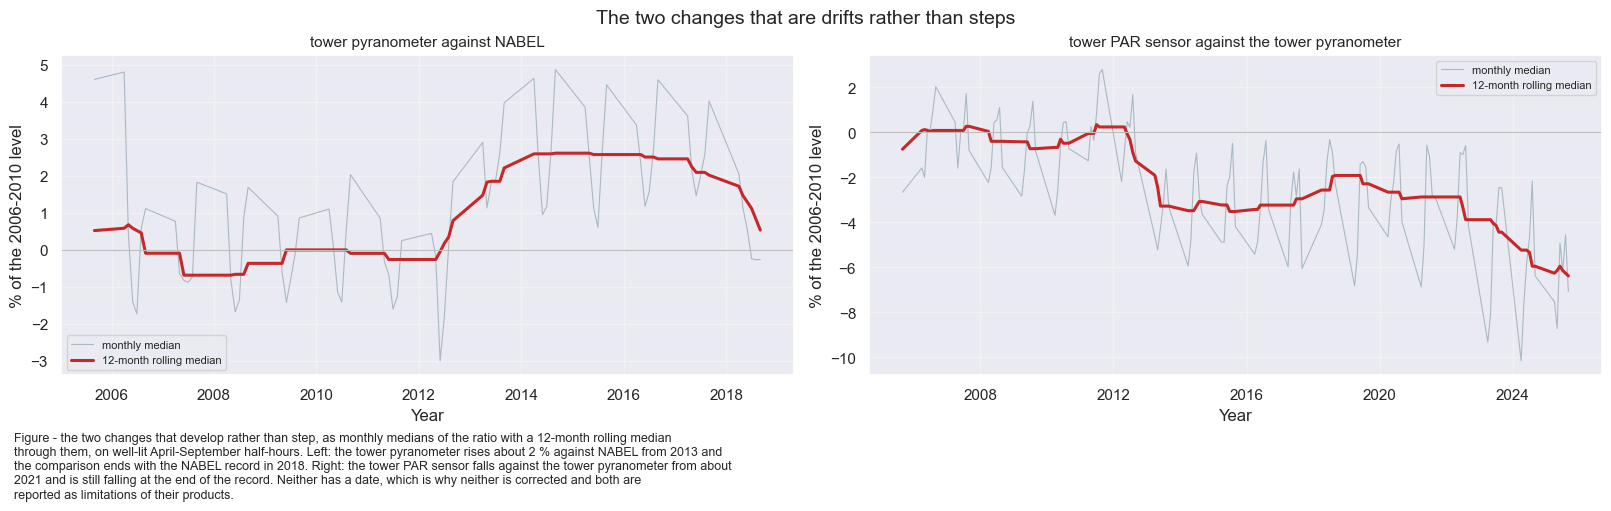

In [16]:
# The two ongoing changes drawn on their own, since neither is a step and a yearly table hides
# that. Monthly medians behind a 12-month rolling median, so the shape is visible rather than
# only the level.
fig, axs = plt.subplots(ncols=2, figsize=(16, 5), dpi=100, layout="constrained")
fig.suptitle("The two changes that are drifts rather than steps", fontsize=14)

for _ax, _num, _den, _title in [
        (axs[0], TOWER_SW, NABEL_SW, 'tower pyranometer against NABEL'),
        (axs[1], TOWER_PPFD, TOWER_SW, 'tower PAR sensor against the tower pyranometer')]:
    _j = rad.loc[USABLE, [_num, _den]].dropna()
    _j = _j[(_j[_num] > MIN_IRRADIANCE) & (_j[_den] > MIN_IRRADIANCE)]
    _r = (_j[_num] / _j[_den]).resample('MS').median()
    _n = (_j[_num] / _j[_den]).resample('MS').count()
    _r = _r[_n >= 100]
    _rel = 100 * (_r / _r.loc[f'{BASELINE_YEARS[0]}':f'{BASELINE_YEARS[1]}'].median() - 1)
    _ax.plot(_rel.index, _rel, color='#90A4AE', lw=0.8, alpha=0.7, label='monthly median')
    _ax.plot(_rel.index, _rel.rolling(12, center=True, min_periods=6).median(),
             color='#C62828', lw=2.2, label='12-month rolling median')
    _ax.axhline(0, color='#BDBDBD', lw=0.8)
    _ax.set_title(_title, fontsize=11)
    _ax.set_xlabel("Year")
    _ax.set_ylabel(f"% of the {BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} level")
    _ax.grid(alpha=0.3)
    _ax.legend(fontsize=8)

figcap(fig, "the two changes that develop rather than step, as monthly medians of the ratio with "
            "a 12-month rolling median through them, on well-lit April-September half-hours. "
            "Left: the tower pyranometer rises about 2 % against NABEL from 2013 and the "
            "comparison ends with the NABEL record in 2018. Right: the tower PAR sensor falls "
            "against the tower pyranometer from about 2021 and is still falling at the end of the "
            "record. Neither has a date, which is why neither is corrected and both are reported "
            "as limitations of their products.")


***


## ✅ What this notebook establishes


In [17]:
# The findings, and what each one is for. Built from the objects above rather than typed out, so
# a re-run that changes a number changes this table too.
tabcap("what this notebook establishes, and which notebook each finding belongs to")
_summary = pd.DataFrame([
    {'when': f'Oct {EVENT_2010}', 'sensor': MS_SW,
     'size (%)': scan.loc[EVENT_2010, f'{TOWER_SW} / {MS_SW}'],
     'documented': 'yes, by the reference file itself',
     'belongs to': '01, 03 (driver); 02 (covariate)'},
    {'when': f'Jan {BREAK_2016}', 'sensor': 'none',
     'size (%)': scan.loc[BREAK_2016].abs().max(),
     'documented': 'logger replaced, sensor not', 'belongs to': '01, 03'},
    {'when': f'from {EVENT_TOWER - 1}', 'sensor': TOWER_SW,
     'size (%)': _local.loc[DEPARTURE, f'{TOWER_SW} / {NABEL_SW}'].max(),
     'documented': 'no', 'belongs to': '01'},
    {'when': f'Dec {CNR4_YEAR - 1}', 'sensor': 'none',
     'size (%)': scan.loc[CNR4_YEAR, f'{TOWER_SW} / {MS_SW}'],
     'documented': 'CNR1 replaced by CNR4', 'belongs to': '01'},
    {'when': f'from {DECLINE_FROM + 1}', 'sensor': TOWER_PPFD,
     'size (%)': min(_fall.values()), 'documented': 'no', 'belongs to': '03'},
]).set_index('when')
display(_summary.round(2))

print("\nNothing here is corrected in any product. Two of the five findings are level changes at "
      "sensors this dataset does not own, and the two that are ours develop over years rather "
      "than stepping at a date, so no correction could be applied at a boundary. They are "
      "recorded so that a data user meets them in the documentation rather than in the data.")


Table - what this notebook establishes, and which notebook each finding belongs to



,sensor,size (%),documented,belongs to
when,,,,
Oct 2010,MeteoSwiss SW_IN,-3.63,"yes, by the reference file itself","01, 03 (driver); 02 (covariate)"
Jan 2016,none,1.35,"logger replaced, sensor not","01, 03"
from 2013,tower SW_IN 47 m,3.28,no,01
Dec 2021,none,-0.84,CNR1 replaced by CNR4,01
from 2022,tower PPFD_IN 47 m,-3.72,no,03



Nothing here is corrected in any product. Two of the five findings are level changes at sensors this dataset does not own, and the two that are ours develop over years rather than stepping at a date, so no correction could be applied at a boundary. They are recorded so that a data user meets them in the documentation rather than in the data.


***


## End of notebook


In [18]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")


Started:  2026-07-28 21:55:32
Finished: 2026-07-28 21:55:45
Runtime:  00:00:13 (hh:mm:ss)
